# Customising a mock survey

In this example, we demonstrate how to put in a custom survey specification in terms of frequency range and sky area.

In [ ]:
import numpy as np
from meer21cm import Specification, MockSimulation
from meer21cm.util import create_wcs_with_range, create_wcs
from meer21cm.plot import plot_map
from meer21cm.util import redshift_to_freq
import meer21cm
import pickle
import matplotlib.pyplot as plt
from astropy.wcs import WCS
data_dir = meer21cm.__file__.rsplit("/", 1)[0] + "/data/"


## Default

By default, when you create a default `Specfication` (which is also the base class for everything else such as `PowerSpectrum` or `MockSimulation`), the specs follow the MeerKLASS L-band deep survey when you specify:

In [2]:
sp = Specification(
    survey='meerklass_2021',
    band='L',
)

In [3]:
sp.z_ch.min(),sp.z_ch.max(),sp.freq_resol

(np.float64(0.38764963174851164),
 np.float64(0.4626012258024983),
 np.float64(208984.375))

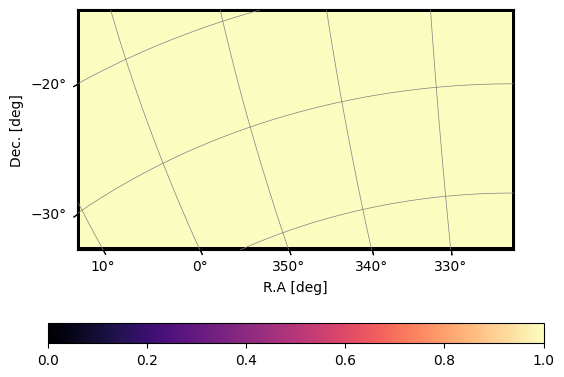

In [4]:
plot_map(sp.W_HI,sp.wproj)

Note that, the area specified by `wproj` is typically larger than the actual area as a buffer. For example, if you put in the actual survey range for MeerKLASS L-band, `meer21cm` will recognise and create a survey selection function automatically. For praticatical purposes, the edge of the `wproj` area is always set to `False` as shown above. If you put in a specific range:


In [5]:
raminMK,ramaxMK = 334,357
decminMK,decmaxMK = -35,-26.5
ra_range = (raminMK,ramaxMK)
dec_range = (decminMK,decmaxMK)
sp = Specification(
    survey='meerklass_2021',
    band='L',
    ra_range=ra_range,
    dec_range=dec_range,
)

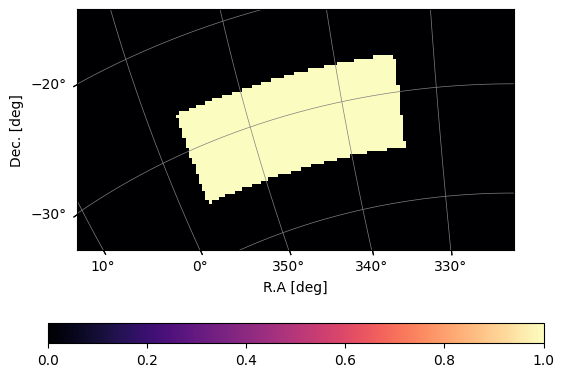

In [6]:
plot_map(sp.W_HI,sp.wproj)

You can see that the selection function is automatically updated.

## Custom redshift bin

Customising the redshift range is easy by simply setting custom frequency channels. Note that however, `meer21cm` **does not** support equally spaced redshift channeles or equally spaced comoving distance channels, and **assumes** that frequency channels are equally spaced. This should be the case for any radio survey.

Suppose you want approximately z=0.5-1.0, with a frequency resolution of 1MHz:

In [8]:
z_min = 0.5
z_max = 1.0
freq_resol = 1e6
num_ch = int((redshift_to_freq(z_min)-redshift_to_freq(z_max))/freq_resol)
nu = np.linspace(0,num_ch-1,num_ch) * freq_resol + redshift_to_freq(z_max)

In [9]:
sp = Specification(
    nu = nu,
    wproj = sp.wproj,
    num_pix_x = sp.num_pix_x,
    num_pix_y = sp.num_pix_y,
)

In [10]:
sp.z_ch.min(),sp.z_ch.max(),sp.freq_resol

(np.float64(0.5027522535193767), np.float64(1.0), np.float64(1000000.0))

The area will still be the default:

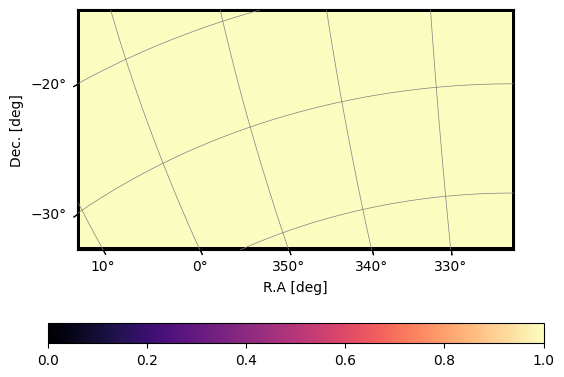

In [11]:
plot_map(sp.W_HI,sp.wproj)

## Custom survey area

Custom survey area is a little bit more complicated. `meer21cm` uses `astropy.wcs.WCS` for mapping the pixels to the sky coordinates. It relies on two ingredients: the `wcs` for projection, and `(num_pix_x, num_pix_y)` for array dimensions.

MeerKLASS has two map formats: FITS outputs from katcali, and pickle outputs from museek.

If you already have an actual data stored in a fits file, the best way to do this is to extract from that:

In [12]:
# fits file
map_file = data_dir + "test_fits.fits" # this is a dummy file just for illustration
wcs = WCS(map_file)
# extract the 2D array dimensions
num_pix_x,num_pix_y, _= wcs.array_shape
# you need to drop the axes that are not angular
wproj = wcs.dropaxis(-1)

In [13]:
sp = Specification(
    wproj=wproj,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
)

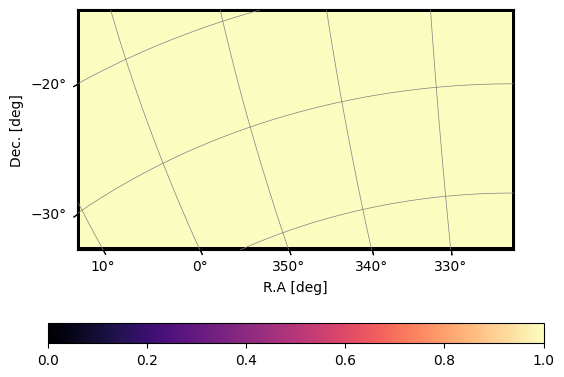

In [14]:
plot_map(sp.W_HI,sp.wproj)

In [21]:
# pickel file
map_file = data_dir + "test.pickle" # this is a dummy file just for illustration
with open(map_file,'rb') as f:
    import pickle
    map_data = pickle.load(f)
    wproj = map_data['wcs']
    num_pix_x,num_pix_y,_ = map_data['map'].shape
sp = Specification(
    wproj=wproj,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
)

If you are starting from scratch, you can use `create_wcs_with_range` or `create_wcs`. `create_wcs_with_range` needs `ra_range`, `dec_range`, angular resolution, and coordinate type as input (see documentation for more details). Let's say we are making a roughly 20x20 deg^2 area with 0.5 deg resolution:

In [22]:
ramincustom,ramaxcustom = -10,10
decmincustom,decmaxcustom = -10,10
ra_range = (ramincustom,ramaxcustom)
dec_range = (decmincustom,decmaxcustom)
ang_resol = 0.5
wproj,num_pix_x,num_pix_y = create_wcs_with_range(
    ra_range,
    dec_range,
    resol=[ang_resol,ang_resol],
)

sp = Specification(
    wproj=wproj,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    ra_range=ra_range,
    dec_range=dec_range,
)

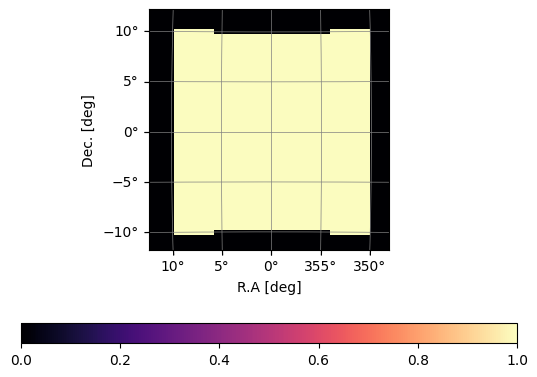

In [23]:
plot_map(sp.W_HI,sp.wproj)

The `wcs` always leave a bit more empty space as buffer. Note that, in some extreme cases, the default buffer `[1.2,1.2]` may not be enough to cover the range:

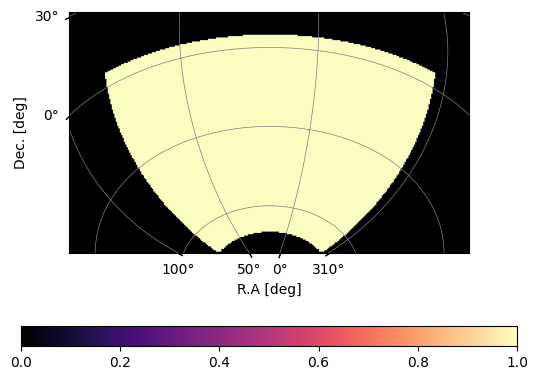

In [24]:
# note that (315,80) is different from (80,315)
ramincustom,ramaxcustom = 315,80
decmincustom,decmaxcustom = -70,5
ra_range = (ramincustom,ramaxcustom)
dec_range = (decmincustom,decmaxcustom)
ang_resol = 0.5
wproj,num_pix_x,num_pix_y = create_wcs_with_range(
    ra_range,
    dec_range,
    resol=[ang_resol,ang_resol],
)

sp = Specification(
    wproj=wproj,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    ra_range=ra_range,
    dec_range=dec_range,
)
plot_map(sp.W_HI,sp.wproj)

You should therefore always examine this and change if needed:

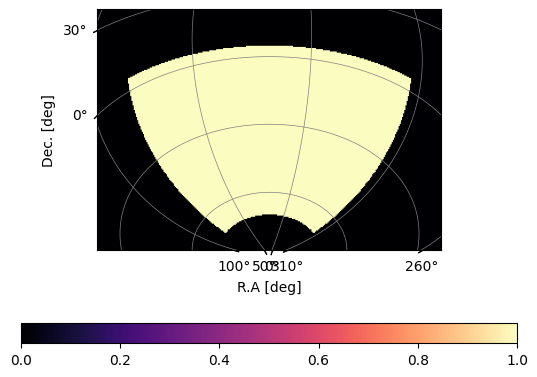

In [25]:
wproj,num_pix_x,num_pix_y = create_wcs_with_range(
    ra_range,
    dec_range,
    resol=[ang_resol,ang_resol],
    buffer=[1.2,1.4],
)

sp = Specification(
    wproj=wproj,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    ra_range=ra_range,
    dec_range=dec_range,
)
plot_map(sp.W_HI,sp.wproj)

If you know exactly how you want to centre your survey area, you can instead use `create_wcs`:

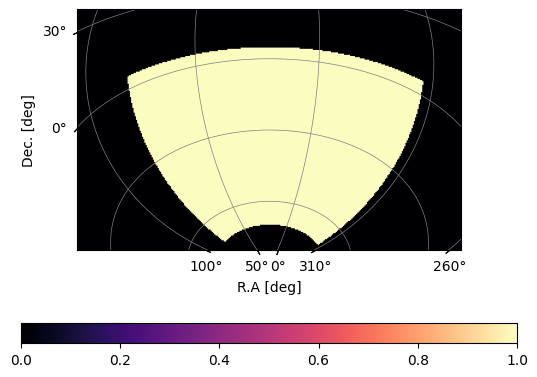

In [35]:
num_pix_x = 320
num_pix_y = 200
ra_cen = 20
dec_cen = -30
ang_resol = 0.5
wproj = create_wcs(
    ra_cen,
    dec_cen,
    [num_pix_x,num_pix_y],
    ang_resol,
)
sp = Specification(
    wproj=wproj,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    ra_range=ra_range,
    dec_range=dec_range,
)
plot_map(sp.W_HI,sp.wproj)

An example to generate a mock observation with custom specs:

In [40]:
ramincustom,ramaxcustom = -10,10
decmincustom,decmaxcustom = -10,10
ra_range = (ramincustom,ramaxcustom)
dec_range = (decmincustom,decmaxcustom)
ang_resol = 0.5
wproj,num_pix_x,num_pix_y = create_wcs_with_range(
    ra_range,
    dec_range,
    resol=[ang_resol,ang_resol],
)

mock = MockSimulation(
    nu=nu,
    wproj=wproj,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    ra_range=ra_range,
    dec_range=dec_range,
    tracer_bias_1=1.5,
    tracer_bias_2=1.5,
    num_discrete_source=10000,
    mean_amp_1='average_hi_temp',
    downres_factor_radial = 2.0,
    downres_factor_transverse = 2.0,
    box_buffkick = 30.0,
    grid_scheme = 'cic',
)

Let us check the survey lightcone:

In [41]:
mock.get_enclosing_box()

In [42]:
mock.grid_data_to_field();

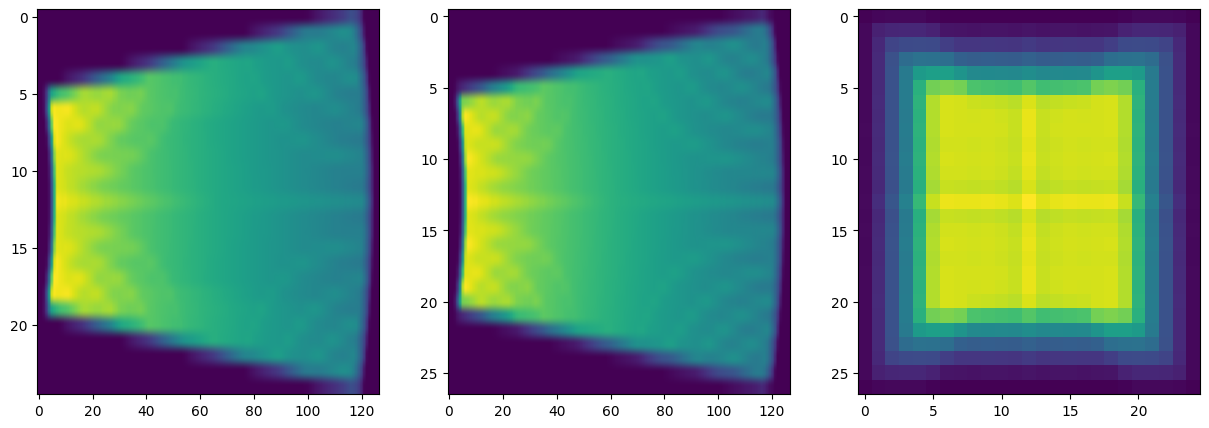

In [43]:
fig,axes = plt.subplots(1,3,figsize=(15,5))
for i,ax in enumerate(axes):
    ax.imshow(mock.counts_in_box.mean(i),aspect='auto')